In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
from scipy.stats import zscore

plt.rcParams["font.family"] = "Malgun Gothic"   # Windows
plt.rcParams["axes.unicode_minus"] = False

In [2]:
analysis = pd.read_csv('../../data/busan_youth_v4.csv', index_col='Unnamed: 0')
analysis.head(2)

,연도,행정구역,연앙인구수(천명),재정자립도(%),통계방식변경,상용월평균급여(원),문화예술활동(건),대학수(천명당),문화기반시설수(십만명당),기업밀도,지역내총생산(십억원),청년_19_29_증감률(%),청년_30_39_증감률(%)
0,2016,강원특별자치도,1536.2750,22.40,0.0,3023906.0,1444.0,0.012368,13.734520,351.305988,44677.444,1.149646,-2.070627
1,2016,경기도,12509.4835,61.61,0.0,3328379.0,3925.0,0.006235,4.028943,2230.077238,433443.961,1.820153,-0.773010


In [3]:
analysis.columns

Index(['연도', '행정구역', '연앙인구수(천명)', '재정자립도(%)', '통계방식변경', '상용월평균급여(원)',
       '문화예술활동(건)', '대학수(천명당)', '문화기반시설수(십만명당)', '기업밀도', '지역내총생산(십억원)',
       '청년_19_29_증감률(%)', '청년_30_39_증감률(%)'],
      dtype='object')

In [4]:
# 2차 변수 분류
# 종속변수
y_cols = analysis[['청년_19_29_증감률(%)', '청년_30_39_증감률(%)']]

# 독립변수
x_cols = analysis[['상용월평균급여(원)', '문화예술활동(건)', 
                '대학수(천명당)', '문화기반시설수(십만명당)', '기업밀도']]

# 모델링용 독립변수
x_cols_control = analysis[['상용월평균급여(원)', '문화예술활동(건)', 
                '대학수(천명당)', '문화기반시설수(십만명당)', '기업밀도', '통계방식변경']]


# 통제변수
meta_cols = analysis[['연앙인구수(천명)', '재정자립도(%)', '지역내총생산(십억원)']]

# Group by
group_cols = analysis[['연도', '행정구역']]

In [5]:
def add_yearly_zscore(df, col, group="연도"):
    mean = df.groupby(group)[col].transform("mean")
    std = df.groupby(group)[col].transform("std")
    return (df[col] - mean) / std


In [6]:
analysis_z = analysis.copy()

analysis_z['청년_19_29_z'] = add_yearly_zscore(
    analysis_z, '청년_19_29_증감률(%)'
)

analysis_z['청년_30_39_z'] = add_yearly_zscore(
    analysis_z, '청년_30_39_증감률(%)'
)


In [7]:
x_vars = [
    '상용월평균급여(원)',
    '문화예술활동(건)',
    '대학수(천명당)',
    '문화기반시설수(십만명당)',
    '기업밀도'
]

for col in x_vars:
    analysis_z[f'{col}_z'] = add_yearly_zscore(analysis_z, col)


In [8]:
meta_vars = [
    '연앙인구수(천명)',
    '재정자립도(%)',
    '지역내총생산(십억원)'
]

for col in meta_vars:
    analysis_z[f'{col}_z'] = add_yearly_zscore(analysis_z, col)


In [9]:
busan_z_mean = (
    analysis_z[analysis_z['행정구역'] == '부산광역시']
    [['청년_19_29_z', '청년_30_39_z']
    + [f'{c}_z' for c in x_vars]
    + [f'{c}_z' for c in meta_vars]]
    .mean()
).sort_values()   # 보기 좋게 정렬(선택)


busan_z_mean


문화기반시설수(십만명당)_z   -0.836676
대학수(천명당)_z        -0.675158
청년_19_29_z        -0.613619
상용월평균급여(원)_z      -0.560950
청년_30_39_z        -0.320986
지역내총생산(십억원)_z     -0.151334
문화예술활동(건)_z        0.105148
연앙인구수(천명)_z        0.107177
기업밀도_z             0.180295
재정자립도(%)_z         0.438308
dtype: float64

### 박스플롯

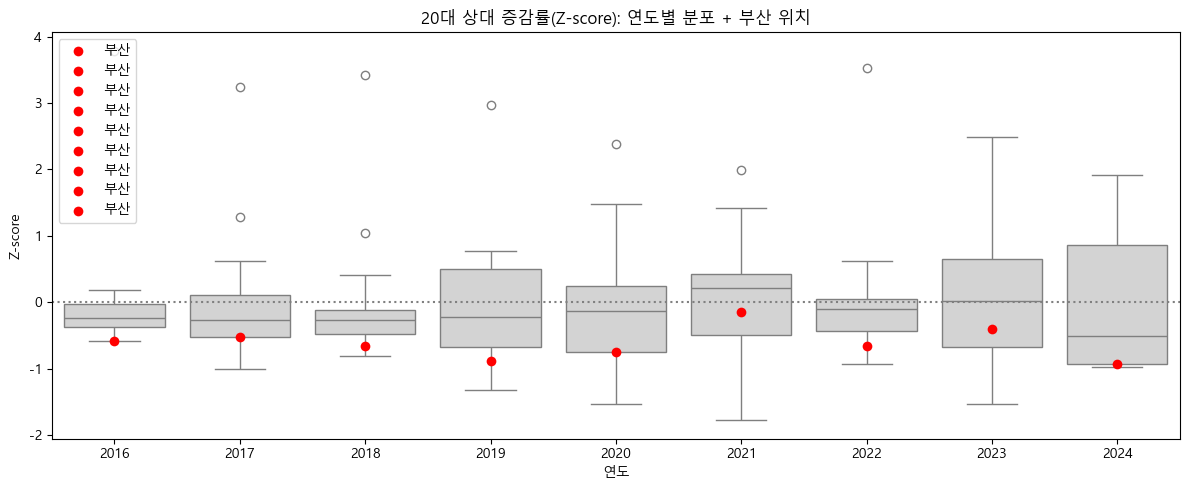

In [10]:
plt.figure(figsize=(12,5))
sb.boxplot(data=analysis_z, x="연도", y="청년_19_29_z", color="lightgray")

busan_df = analysis_z[analysis_z["행정구역"]=="부산광역시"]
sb.stripplot(
    data=busan_df, x="연도", y="청년_19_29_z",
    color="red", size=7, jitter=0, label="부산"
)

plt.axhline(0, linestyle=":", color="gray")
plt.title("20대 상대 증감률(Z-score): 연도별 분포 + 부산 위치")
plt.xlabel("연도"); plt.ylabel("Z-score")
plt.legend()
plt.tight_layout()
plt.show()


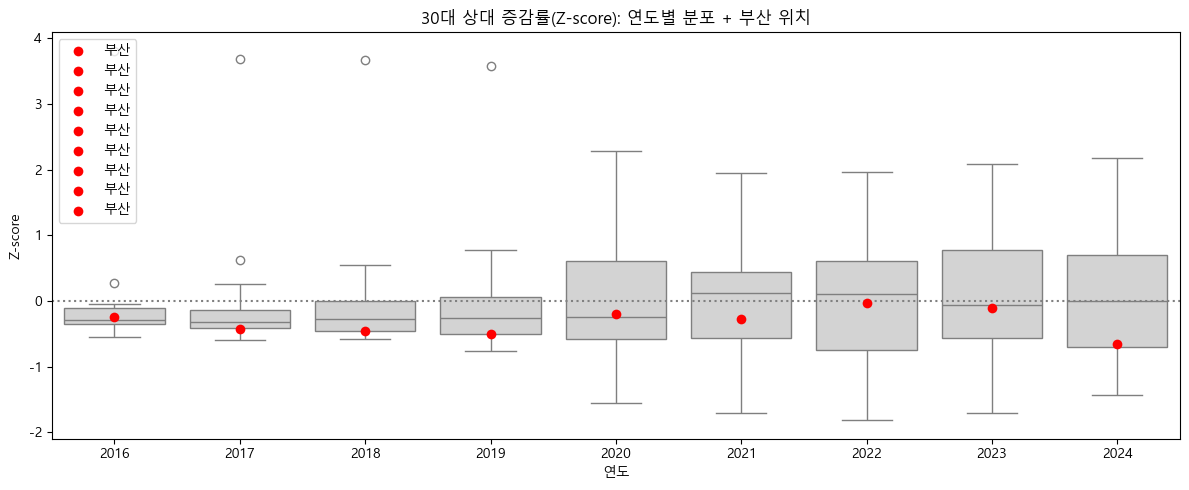

In [11]:
plt.figure(figsize=(12,5))
sb.boxplot(data=analysis_z, x="연도", y="청년_30_39_z", color="lightgray")

busan_df = analysis_z[analysis_z["행정구역"]=="부산광역시"]
sb.stripplot(
    data=busan_df, x="연도", y="청년_30_39_z",
    color="red", size=7, jitter=0, label="부산"
)

plt.axhline(0, linestyle=":", color="gray")
plt.title("30대 상대 증감률(Z-score): 연도별 분포 + 부산 위치")
plt.xlabel("연도"); plt.ylabel("Z-score")
plt.legend()
plt.tight_layout()
plt.show()


In [12]:
# 1) 2016~2024만 필터링 (중요)
analysis_8 = analysis[analysis["연도"].between(2016, 2024)].copy()

# 2) 8개년 전체 분포 기준 Z-score 생성
z8_cols = [
    "청년_19_29_증감률(%)",
    "청년_30_39_증감률(%)",
    *x_vars,
    *meta_vars
]

for col in z8_cols:
    analysis_8[f"{col}_z8"] = zscore(analysis_8[col], nan_policy="omit")

In [13]:
busan_z8_mean = (
    analysis_8[analysis_8["행정구역"]=="부산광역시"]
    [[f"{c}_z8" for c in z8_cols]]
    .mean()
    .sort_values()
)

busan_z8_mean


문화기반시설수(십만명당)_z8     -0.856517
대학수(천명당)_z8          -0.695929
상용월평균급여(원)_z8        -0.469253
청년_19_29_증감률(%)_z8   -0.429730
청년_30_39_증감률(%)_z8   -0.279869
지역내총생산(십억원)_z8       -0.154943
문화예술활동(건)_z8          0.107046
연앙인구수(천명)_z8          0.110128
기업밀도_z8               0.173819
재정자립도(%)_z8           0.453439
dtype: float64

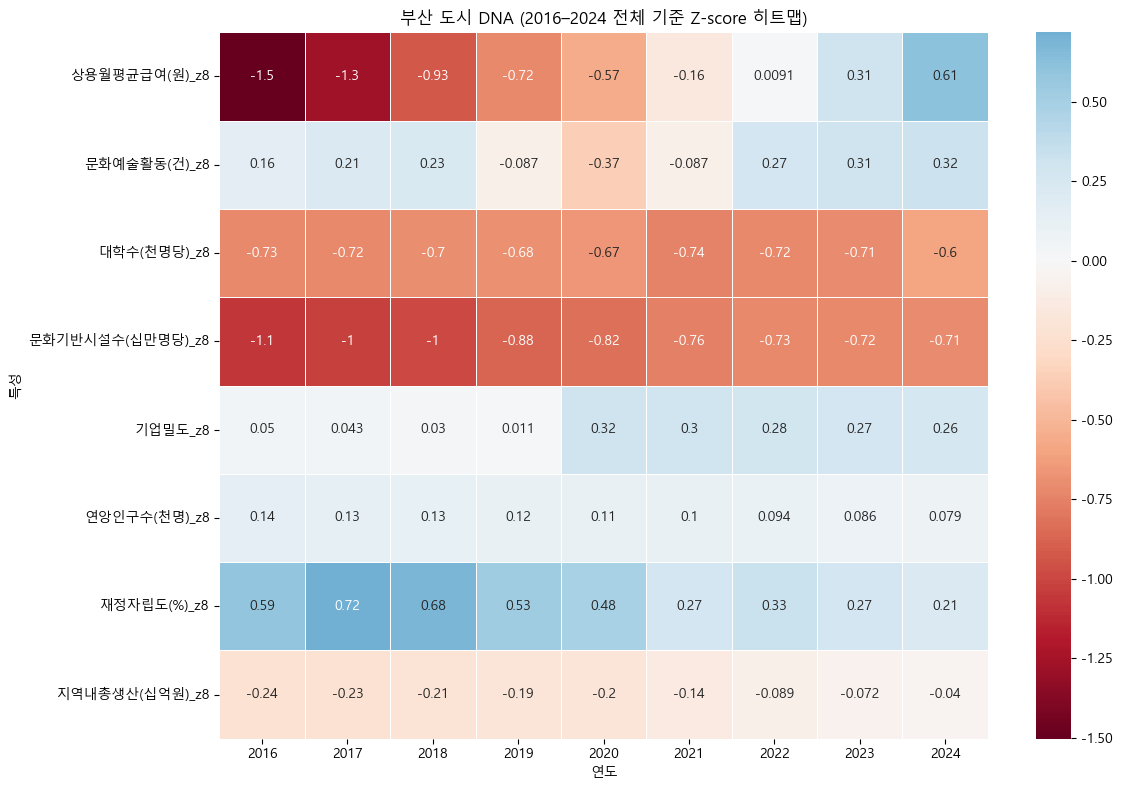

In [14]:
# 부산만: 연도 x 8개 특성(Z8)
busan_8 = analysis_8[analysis_8["행정구역"]=="부산광역시"].sort_values("연도")

dna_z8_cols = [f"{c}_z8" for c in x_vars + meta_vars]  # 8개 특성만
mat = busan_8.set_index("연도")[dna_z8_cols]

plt.figure(figsize=(12,8))
sb.heatmap(mat.T, cmap="RdBu", center=0, linewidths=0.5, annot=True)
plt.title("부산 도시 DNA (2016–2024 전체 기준 Z-score 히트맵)")
plt.xlabel("연도"); plt.ylabel("특성")
plt.tight_layout()
plt.show()


### 부산 구조 + 청년 증감률 통합 히트맵

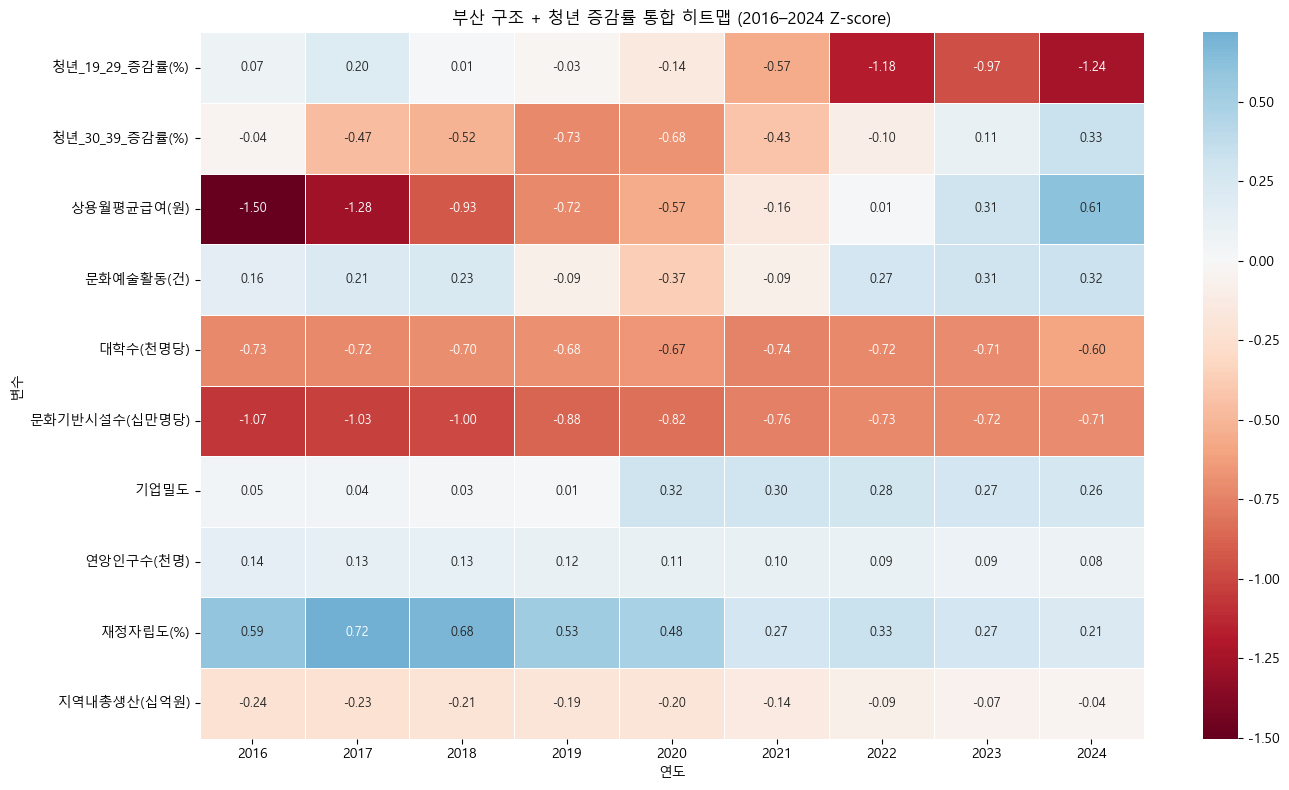

In [15]:
# 히트맵에 포함할 변수 (구조 + 결과)
heat_vars = [
    "청년_19_29_증감률(%)",
    "청년_30_39_증감률(%)",
    *x_vars,
    *meta_vars
]

analysis_hm = analysis[analysis["연도"].between(2016, 2024)].copy()

# 8개년 기준 Z-score
for col in heat_vars:
    analysis_hm[f"{col}_z8"] = zscore(analysis_hm[col], nan_policy="omit")

# 부산만 추출
busan_hm = (
    analysis_hm[analysis_hm["행정구역"]=="부산광역시"]
    .sort_values("연도")
    .set_index("연도")
)

hm_cols = [f"{c}_z8" for c in heat_vars]
mat_all = busan_hm[hm_cols].T

fig, ax = plt.subplots(figsize=(14,8))
sb.heatmap(
    mat_all,
    cmap="RdBu",
    center=0,
    linewidths=0.5,
    annot=True,
    fmt=".2f",
    annot_kws={"size":9}
)
new_labels = [
    "청년_19_29_증감률(%)",
    "청년_30_39_증감률(%)",
    "상용월평균급여(원)",
    "문화예술활동(건)",
    "대학수(천명당)",
    "문화기반시설수(십만명당)",
    "기업밀도",
    "연앙인구수(천명)",
    "재정자립도(%)",
    "지역내총생산(십억원)"
]

ax.set_yticklabels(new_labels, rotation=0)

plt.title("부산 구조 + 청년 증감률 통합 히트맵 (2016–2024 Z-score)")
plt.xlabel("연도")
plt.ylabel("변수")
plt.tight_layout()
plt.show()


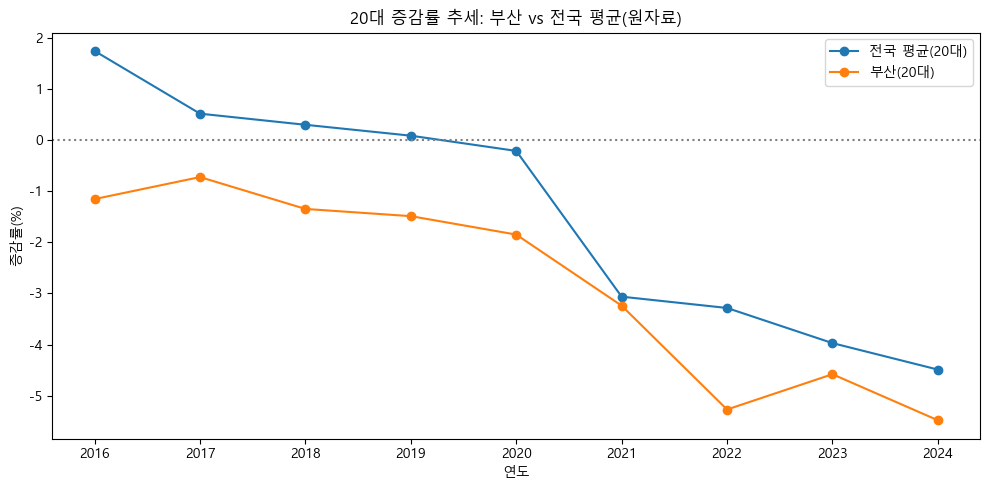

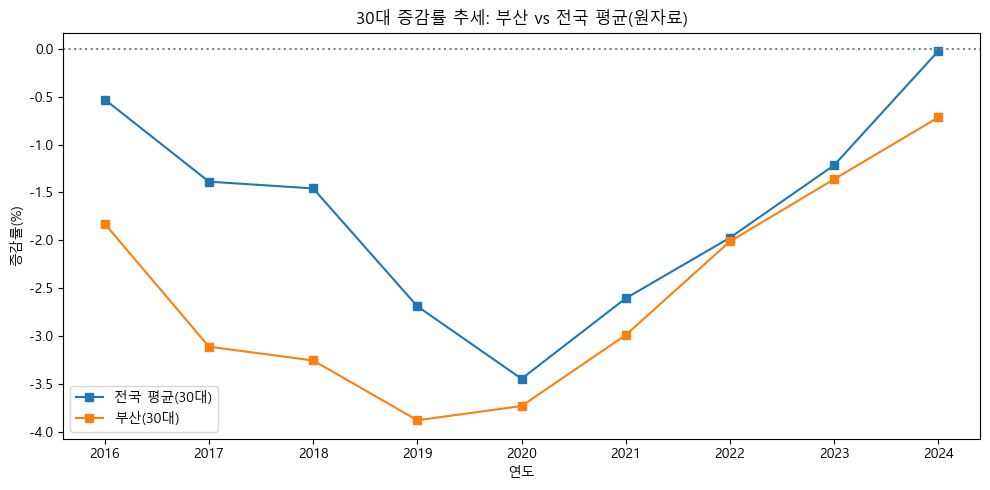

In [16]:
# 2016~2024만 사용 (필수)
df = analysis[analysis["연도"].between(2016, 2024)].copy()

# 비교할 변수(원자료)
gap_vars = [
    "청년_19_29_증감률(%)",
    "청년_30_39_증감률(%)",
    *x_vars,
    *meta_vars
]

# 전국 평균
avg = df.groupby("연도")[gap_vars].mean()

# 부산 값
busan = df[df["행정구역"]=="부산광역시"].set_index("연도")[gap_vars]

# 부산-전국 평균 gap
gap = (busan - avg).reset_index()  # 연도가 index라 reset

# 전국 평균(연도별)
avg_y = df.groupby("연도")[["청년_19_29_증감률(%)","청년_30_39_증감률(%)"]].mean().reset_index()

# 부산(연도별)
busan_y = (df[df["행정구역"]=="부산광역시"]
            [["연도","청년_19_29_증감률(%)","청년_30_39_증감률(%)"]]
            .sort_values("연도"))

# 20대
plt.figure(figsize=(10,5))
plt.plot(avg_y["연도"], avg_y["청년_19_29_증감률(%)"], marker="o", label="전국 평균(20대)")
plt.plot(busan_y["연도"], busan_y["청년_19_29_증감률(%)"], marker="o", label="부산(20대)")
plt.axhline(0, linestyle=":", color="gray")
plt.title("20대 증감률 추세: 부산 vs 전국 평균(원자료)")
plt.xlabel("연도"); plt.ylabel("증감률(%)")
plt.legend(); plt.tight_layout(); plt.show()

# 30대
plt.figure(figsize=(10,5))
plt.plot(avg_y["연도"], avg_y["청년_30_39_증감률(%)"], marker="s", label="전국 평균(30대)")
plt.plot(busan_y["연도"], busan_y["청년_30_39_증감률(%)"], marker="s", label="부산(30대)")
plt.axhline(0, linestyle=":", color="gray")
plt.title("30대 증감률 추세: 부산 vs 전국 평균(원자료)")
plt.xlabel("연도"); plt.ylabel("증감률(%)")
plt.legend(); plt.tight_layout(); plt.show()


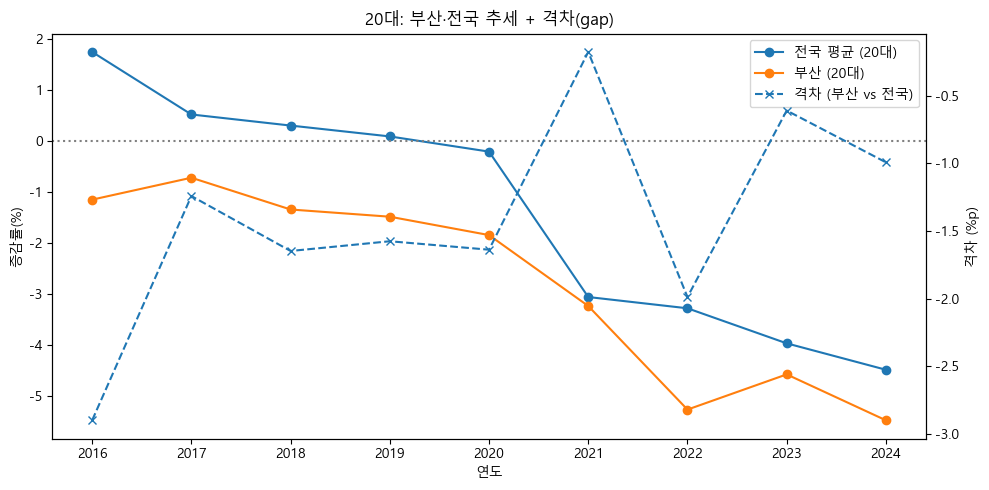

In [17]:
# 덤벨 차트로 표현해보기

fig, ax1 = plt.subplots(figsize=(10,5))

# 왼쪽 y축: 전국 평균 & 부산
l1, = ax1.plot(
    avg_y["연도"], avg_y["청년_19_29_증감률(%)"],
    marker="o", label="전국 평균 (20대)"
)
l2, = ax1.plot(
    busan_y["연도"], busan_y["청년_19_29_증감률(%)"],
    marker="o", label="부산 (20대)"
)

ax1.axhline(0, linestyle=":", color="gray")
ax1.set_xlabel("연도")
ax1.set_ylabel("증감률(%)")

# 오른쪽 y축: gap
ax2 = ax1.twinx()
l3, = ax2.plot(
    gap["연도"], gap["청년_19_29_증감률(%)"],
    marker="x", linestyle="--", label="격차 (부산 vs 전국)"
)
ax2.set_ylabel("격차 (%p)")

# legend 수동 결합
lines = [l1, l2, l3]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="best")

plt.title("20대: 부산·전국 추세 + 격차(gap)")
plt.tight_layout()
plt.show()


In [18]:
busan_ts = (
    analysis_8[analysis_8["행정구역"]=="부산광역시"]
    .sort_values("연도")
    .set_index("연도")
)


---

### 20대 추세선

(이동·유출 민감 / 기회 요인 중심)

구성 논리

결과: 20대 증감률

구조: 임금, 기업밀도, 문화기반
→ “일자리·기회는 개선되는데 20대는 왜 떠나는가?”

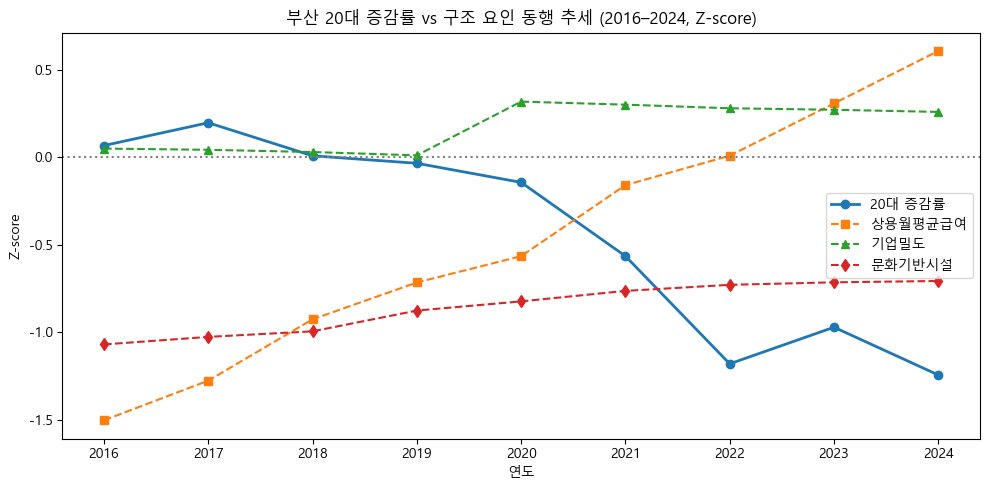

In [19]:
plt.figure(figsize=(10,5))

plt.plot(
    busan_ts.index,
    busan_ts["청년_19_29_증감률(%)_z8"],
    marker="o", linewidth=2, label="20대 증감률"
)

plt.plot(
    busan_ts.index,
    busan_ts["상용월평균급여(원)_z8"],
    marker="s", linestyle="--", label="상용월평균급여"
)

plt.plot(
    busan_ts.index,
    busan_ts["기업밀도_z8"],
    marker="^", linestyle="--", label="기업밀도"
)

plt.plot(
    busan_ts.index,
    busan_ts["문화기반시설수(십만명당)_z8"],
    marker="d", linestyle="--", label="문화기반시설"
)

plt.axhline(0, linestyle=":", color="gray")
plt.title("부산 20대 증감률 vs 구조 요인 동행 추세 (2016–2024, Z-score)")
plt.xlabel("연도")
plt.ylabel("Z-score")
plt.legend()
plt.tight_layout()
plt.show()


구조 변수는 2020 이후 개선

하지만 20대 증감률은 2021 이후 급락

👉 ‘기회는 늘었지만 체류 유인은 부족’ 가능성

---


### 30대 기준 추세선

(정착·생활 안정 요인 중심)

구성 논리

결과: 30대 증감률

구조: 재정자립도, 문화기반, GRDP
→ “정착 가능한 조건이 회복되면 30대는 반응하는가?”

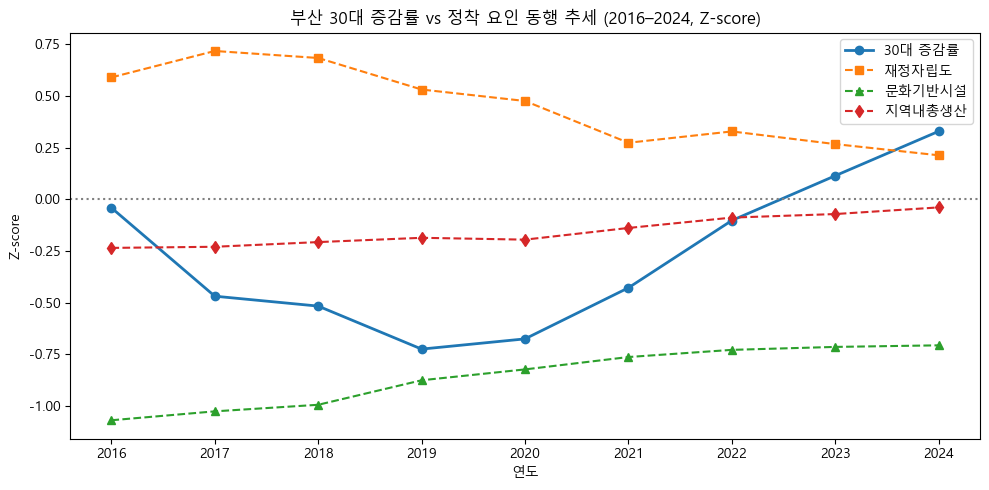

In [20]:
plt.figure(figsize=(10,5))

plt.plot(
    busan_ts.index,
    busan_ts["청년_30_39_증감률(%)_z8"],
    marker="o", linewidth=2, label="30대 증감률"
)

plt.plot(
    busan_ts.index,
    busan_ts["재정자립도(%)_z8"],
    marker="s", linestyle="--", label="재정자립도"
)

plt.plot(
    busan_ts.index,
    busan_ts["문화기반시설수(십만명당)_z8"],
    marker="^", linestyle="--", label="문화기반시설"
)

plt.plot(
    busan_ts.index,
    busan_ts["지역내총생산(십억원)_z8"],
    marker="d", linestyle="--", label="지역내총생산"
)

plt.axhline(0, linestyle=":", color="gray")
plt.title("부산 30대 증감률 vs 정착 요인 동행 추세 (2016–2024, Z-score)")
plt.xlabel("연도")
plt.ylabel("Z-score")
plt.legend()
plt.tight_layout()
plt.show()


2020~2022년 구조 지표 개선

같은 시기 30대 증감률도 완화·회복

👉 30대는 ‘정착 조건’에 반응하는 패턴

20대 청년은 일자리·산업 여건이 개선되는 상황에서도 지속적으로 유출되는 반면,
30대 청년은 재정·생활 여건이 개선될 경우 인구 감소가 완화되는 경향을 보였다.

"증감률 대신 독립 변수들에 대한 추세, 비슷한 양상을 띄는 지역이나, 반대되는 지역을 보기"